# **imports**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent)) # Damit Dataset richtig erkannt wird

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
import PIL.Image as Image
import os
import cv2
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torch
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import math

from SelfAttention.self_attention import SelfAttention
from SelfAttention.MLP import MLP

from TransformerBlocks.ImageTransformerBlock import ImageTransformerBlock
from TransformerBlocks.PointTransformerBlock import PointTransformerBlock

from UNet import FeatureUNET
from PointNet_.PointNet import PointNetAutoencoder, PointNetAutoencoder, PointNetEncoder2D
from PointNet_.PointNetPreTrainer import PointNetPreTrainer
from Dataset.PH2ContourDataset import PH2ContourDataset
from ContourDiffusionModel import ContourDiffusionModel

# load **DATA**

In [3]:
dataset = PH2ContourDataset(base_path="..\PH2Dataset\PH2 Dataset images", n_punkte=200, img_size=(288, 384)) # eigentlich 576x768, aber das ist zu groß für die GPU. Wir testen erstmal mit 288x384, damit es schneller läuft.

# 2. DataLoader erstellen (z.B. 2 Bilder gleichzeitig verarbeiten)
dataloader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=True)

# 3. Testen, ob alles klappt:
for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  
    print("Punkt-Batch Form:", batch_points.shape)     


Datensatz geladen: 200 Bilder und Masken gefunden.
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])
Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch

Bild-Batch Form: torch.Size([2, 3, 288, 384])
Punkt-Batch Form: torch.Size([2, 200, 2])


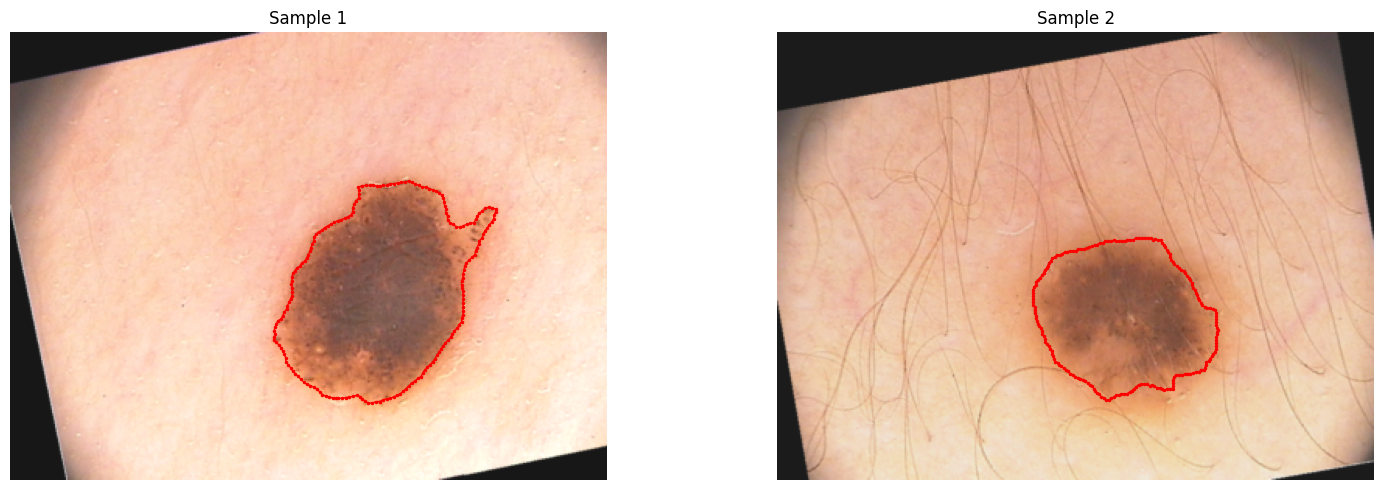

In [4]:

for batch_images, batch_points in dataloader:
    print("Bild-Batch Form:", batch_images.shape)  # Wird (16, 3, 576, 766) sein
    print("Punkt-Batch Form:", batch_points.shape) # Wird (16, 200, 2) sein
    
    # Plot aufrufen
    dataset.verify_dataset(batch_images, batch_points)
    break # Bricht nach dem ersten Batch ab

In [5]:
# Teste das neue Feature-U-Net
model = FeatureUNET(in_channels=3, out_features=64)
test_bild = torch.randn(4, 3, 256, 256) # 4 Dummy-Bilder (Batch, RGB, H, W)

wetterkarte = model(test_bild)
for idxwetter, wetter in enumerate(wetterkarte):
    print(f"Wetterkarte {idxwetter}: {wetter.shape}")

# Erwartet: torch.Size([4, 64, 256, 256])

Wetterkarte 0: torch.Size([4, 256, 32, 32])
Wetterkarte 1: torch.Size([4, 128, 64, 64])
Wetterkarte 2: torch.Size([4, 64, 256, 256])


# **Diffusion Model**

## **PointNet** Pretraining

In [ ]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#model = PointNetAutoencoder(num_points=200)
#
#trainer = PointNetPreTrainer(
#    model=model,
#    dataloader=dataloader,
#    device=device,
#    epochs=200
#)
#
#trainer.train()

Starte PointNet Pre-Training auf cuda...


AE-Epoche 1/200: 100%|██████████| 100/100 [00:05<00:00, 17.11it/s, ChamferLoss=0.25351]


AE-Epoche 1 beendet | Avg Loss: 0.31332 | LR: 0.001
✅ Neuer Rekord! Encoder gespeichert (Loss: 0.31332)


AE-Epoche 2/200: 100%|██████████| 100/100 [00:05<00:00, 17.40it/s, ChamferLoss=0.28915]


AE-Epoche 2 beendet | Avg Loss: 0.29329 | LR: 0.001
✅ Neuer Rekord! Encoder gespeichert (Loss: 0.29329)


...

AE-Epoche 198 beendet | Avg Loss: 0.17122 | LR: 1.52587890625e-08


AE-Epoche 199/200: 100%|██████████| 100/100 [00:05<00:00, 19.70it/s, ChamferLoss=0.13429]


AE-Epoche 199 beendet | Avg Loss: 0.16592 | LR: 1.52587890625e-08


AE-Epoche 200/200: 100%|██████████| 100/100 [00:05<00:00, 19.50it/s, ChamferLoss=0.19421]

AE-Epoche 200 beendet | Avg Loss: 0.16964 | LR: 1.52587890625e-08

Training beendet!
Bester Loss: 0.15593
Gespeichert unter: best_pointnet_expert_weights.pth


In [ ]:
#import matplotlib.pyplot as plt
#import torch
#
#trainer.model.eval()
#
#with torch.no_grad():
#
#    # Ein echtes Sample holen
#    echte_punkte = batch_points[0:1].to(trainer.device)
#
#    # Rekonstruktion
#    fake_punkte, _ = trainer.model(echte_punkte)
#
#    # Nach CPU + numpy
#    echt = echte_punkte[0].cpu().numpy()
#    fake = fake_punkte[0].cpu().numpy()
#
#    # Plot
#    plt.figure(figsize=(8, 8))
#
#    plt.scatter(
#        echt[:, 0],
#        echt[:, 1],
#        c='blue',
#        label='Echte Kontur',
#        alpha=0.5
#    )
#
#    plt.scatter(
#        fake[:, 0],
#        fake[:, 1],
#        c='red',
#        marker='x',
#        label='Rekonstruktion'
#    )
#
#    plt.legend()
#
#    plt.title("Autoencoder Rekonstruktion")
#
#    plt.axis("equal")
#
#    plt.show()

## **Diffusion Model**

# Test

In [ ]:
import torch

# 1. Dummy-Daten erzeugen (als kämen sie aus deinem DataLoader)
batch_size = 4
dummy_bilder = torch.randn(batch_size, 3, 576, 768) # 4 Bilder
dummy_punkte = torch.rand(batch_size, 200, 2) * 2 - 1 # 4x 200 Punkte im Bereich [-1, 1]
dummy_zeit = torch.randint(0, 1000, (batch_size,))  # 4 zufällige Zeitschritte

# 2. Modelle initialisieren (UNSERE NEUE ARCHITEKTUR)
unet = FeatureUNET(in_channels=3, out_features=64)
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128) # context_dim ist weg!

# 3. Den Pipeline-Durchlauf testen!
with torch.no_grad():
    # Phase 1: U-Net (Die 3 Messfühler)
    wetterkarten_liste = unet(dummy_bilder)
    
    print("--- OUTPUT U-NET ---")
    print(f"Anzahl der extrahierten Karten: {len(wetterkarten_liste)}")
    print(f"Shape Karte 1 (Grob):   {wetterkarten_liste[0].shape}") # Erwartet: (4, 256, 72, 96)
    print(f"Shape Karte 2 (Mittel): {wetterkarten_liste[1].shape}") # Erwartet: (4, 128, 144, 192)
    print(f"Shape Karte 3 (Fein):   {wetterkarten_liste[2].shape}") # Erwartet: (4, 64, 576, 768)
    
    # Phase 2: Diffusions-Modell
    predicted_noise = diff_model(dummy_punkte, dummy_zeit, wetterkarten_liste)
    
    print("\n--- OUTPUT DIFFUSION ---")
    print(f"Shape Predicted Noise: {predicted_noise.shape}") # Erwartet: (4, 200, 2)
    
print("\nBOOM! Die neue Coarse-to-Fine Architektur steht und ist mathematisch zu 100 % kompatibel!")

In [ ]:
import torch

# Standard DDPM Parameter
T = 1000 # 1000 Diffusions-Schritte
# Beta ist die Menge an Rauschen, die pro Schritt addiert wird.
# Es fängt winzig an (0.0001) und wird zum Schluss größer (0.02)
betas = torch.linspace(0.0001, 0.02, T) 

# Alphas definieren, wie viel vom Original-Bild noch übrig ist
alphas = 1.0 - betas
# alphas_cumprod ist die kumulierte Summe. (Gibt an, wie viel Original bei Schritt t noch da ist)
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Helper-Funktion, um den richtigen Alpha-Wert für den Zeitschritt t der Batch auszuwählen
def extract(a, t, x_shape):
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Wir holen uns EIN Set an Punkten aus deinem Dataloader
batch_images, batch_points = next(iter(dataloader))
x_0 = batch_points[0] # (200, 2) - Die echten Punkte im Bereich [-1, 1]

# 2. Wir generieren das pure Zufallsrauschen (Gaussian Noise)
# Das ist exakt das, was dein 'noise = torch.randn_like(batch_points)' macht
noise = torch.randn_like(x_0)

# 3. Wir schauen uns drei Zeitpunkte an
zeitpunkte = [0, 50, 999]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, t_val in enumerate(zeitpunkte):
    # Wir holen uns den Skalierungswert für genau diesen Zeitpunkt t
    a_bar = alphas_cumprod[t_val].item()
    
    # DIE MAGISCHE FORMEL (Vorwärts-Diffusion)
    # x_t = (Echter Punkt * restliche Sichtbarkeit) + (Rauschen * aktuelle Rausch-Stärke)
    x_t = (x_0 * (a_bar ** 0.5)) + (noise * ((1 - a_bar) ** 0.5))
    
    # --- PLOTTING ---
    # Wir wandeln die Tensoren in Numpy-Arrays um
    pts = x_t.cpu().numpy()
    
    ax = axes[i]
    # Die Punkte zeichnen (blau)
    ax.scatter(pts[:, 0], pts[:, 1], c='blue', s=10, alpha=0.7)
    
    # Den Ursprung (0, 0) mit einem roten Kreuz markieren
    ax.plot(0, 0, 'rx', markersize=15, markeredgewidth=2, label="Ursprung (0,0)")
    
    # Die Achsen fest auf [-3, 3] setzen, damit wir den Shrink-Effekt sehen!
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.axhline(0, color='black', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='black', linewidth=0.5, linestyle='--')
    ax.set_title(f"Schritt t={t_val}\nAlpha_bar = {a_bar:.4f}")
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
import random 

import torch
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt

# WICHTIG: Ersetze das hier durch deine korrekten Importe für die Modelle
# from models import FeatureUNET, ContourDiffusionModel
# from PointNet import PointNetEncoder2D

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. MODELLE INITIALISIEREN ---
unet = FeatureUNET(in_channels=3, out_features=64).to(device)
diff_model = ContourDiffusionModel(n_punkte=200, hidden_dim=128).to(device)

# --- 2. DEN POINTNET EXPERTEN LADEN UND EINFRIEREN ---
pointnet_expert = PointNetEncoder2D(global_feat_dim=1024).to(device)
pointnet_expert.load_state_dict(torch.load("best_pointnet_expert_weights.pth"))
pointnet_expert.eval() # Eval-Modus: BatchNorm wird eingefroren
for param in pointnet_expert.parameters():
    param.requires_grad = False # Gradienten stoppen, der Experte lernt nicht mehr!

# --- 3. OPTIMIZER & SETTINGS ---
# Beide Modelle in EINEN Optimizer packen
optimizer = optim.AdamW(
    list(unet.parameters()) + list(diff_model.parameters()), 
    lr=1e-4, 
    weight_decay=1e-4
)

EPOCHS = 500 # Das ist nur das Timeout. Dank Checkpointing sicher!
best_loss = float('inf') # Merkt sich den Rekord

unet.train()
diff_model.train()

print(f"Starte Diffusions-Training auf {device}. Du kannst jetzt schlafen gehen! 🌙")
scaler = torch.amp.GradScaler('cuda')

training_history = {
    'epoch': [],
    'loss_noise': [],
    'loss_struktur': [],
    'loss_total': []
}

# --- 4. DIE HAUPT-TRAININGSSCHLEIFE ---
for epoch in range(EPOCHS):
    epoch_loss_total = 0.0
    epoch_loss_noise = 0.0
    epoch_loss_struktur = 0.0
    
    progress_bar = tqdm(dataloader, desc=f"Epoche {epoch+1}/{EPOCHS}")
    
    for batch_images, batch_points in progress_bar:
        batch_images = batch_images.to(device)
        batch_points = batch_points.to(device) 
        batch_size = batch_images.shape[0]
        
        optimizer.zero_grad()
        
        # Zufällige Zeitschritte und reines Rauschen ziehen
        t = torch.randint(0, T, (batch_size,), device=device).long()
        noise = torch.randn_like(batch_points)
        
        with torch.amp.autocast('cuda'):
            # Rauschen auf die Punkte addieren (Vorwärts-Diffusion)
            sqrt_alphas_cumprod_t = extract(torch.sqrt(alphas_cumprod), t, batch_points.shape)
            sqrt_one_minus_alphas_cumprod_t = extract(torch.sqrt(1. - alphas_cumprod), t, batch_points.shape)
            noisy_points = sqrt_alphas_cumprod_t * batch_points + sqrt_one_minus_alphas_cumprod_t * noise
            
            # --- TEIL A: NORMALER DIFFUSIONS-DURCHLAUF ---
            wetterkarten_liste = unet(batch_images)
            if random.random() < 0.15:
                wetterkarten_liste = [torch.zeros_like(k) for k in wetterkarten_liste] # classifier free guidance
    
            predicted_noise = diff_model(noisy_points, t, wetterkarten_liste)
            
            # Basis-Loss (Wie gut wurde das Rauschen geraten?)
            loss_noise = F.mse_loss(predicted_noise, noise)
            
            # --- TEIL B: DER STRUKTUR-LOSS DURCH DEN EXPERTEN ---
            # Wir rechnen das geratene Rauschen zurück in die reinen Punkte (x_0)
            predicted_x0 = (noisy_points - sqrt_one_minus_alphas_cumprod_t * predicted_noise) / sqrt_alphas_cumprod_t
            
            # 🚨 DAS CLAMPING (Verhindert die Loss-Explosion bei hohen t) 🚨
            predicted_x0 = torch.clamp(predicted_x0, min=-1.5, max=1.5)
            
            # Die Fingerabdrücke holen (Latent Space)
            #struktur_gewicht = extract(alphas_cumprod, t, batch_points.shape).mean()
            #latent_real = pointnet_expert(batch_points)
            #latent_fake = pointnet_expert(predicted_x0)
            #loss_struktur = struktur_gewicht * F.mse_loss(latent_fake, latent_real)
            
            # --- NEU: DER RING-LOSS (Chain-Loss) ---
            # Zwingt die 200 Punkte zu einer geschlossenen Kette
            points_next = torch.roll(predicted_x0, shifts=-1, dims=1)
            loss_chain = torch.mean((predicted_x0 - points_next)**2)
            
            # --- TEIL C: LOSS KOMBINIEREN ---
            # Gewichtung: Chain-Loss muss dominant sein, um das Streuband zu killen!
            #loss_total = loss_noise + (0.02 * loss_struktur) + (0.005 * loss_chain)
            loss_total = loss_noise + (0.005 * loss_chain)
            
        # --- 5. OPTIMIERUNG ---
        scaler.scale(loss_total).backward()
        scaler.step(optimizer)
        scaler.update()
        
        epoch_loss_total += loss_total.item()
        epoch_loss_noise += loss_noise.item()
        #epoch_loss_struktur += loss_struktur.item()
        
        progress_bar.set_postfix({
            "Loss": f"{loss_total.item():.4f}", 
            "Noise": f"{loss_noise.item():.4f}", 
        #    "Struktur": f"{loss_struktur.item():.4f}"
        })
        
    # --- 6. EPOCHEN-ABSCHLUSS & CHECKPOINTING ---
    avg_loss_total = epoch_loss_total / len(dataloader)
    avg_loss_noise = epoch_loss_noise / len(dataloader)
    avg_loss_struktur = epoch_loss_struktur / len(dataloader)
    
    training_history['epoch'].append(epoch + 1)
    training_history['loss_total'].append(avg_loss_total)
    training_history['loss_noise'].append(avg_loss_noise)
    training_history['loss_struktur'].append(avg_loss_struktur)
    
    print(f"Epoche {epoch+1} beendet | Total: {avg_loss_total:.4f} | Noise: {avg_loss_noise:.4f} | Struktur: {avg_loss_struktur:.4f}")
    
    # 🌟 DER LEBENSRETTER: Nur speichern, wenn das Modell einen neuen Rekord bricht
    if avg_loss_total < best_loss:
        best_loss = avg_loss_total
        
        # Gewichte speichern (Beide Netzwerke!)
        torch.save({
            'unet_state_dict': unet.state_dict(),
            'diff_model_state_dict': diff_model.state_dict(),
            'epoch': epoch,
            'loss': best_loss
        }, "best_end2end_model.pth")
        
        print(f"✅ Neuer Rekord! Bestes Modell in Epoche {epoch+1} gesichert (Loss: {best_loss:.4f})")

In [ ]:
# WICHTIG: Die Keys müssen exakt mit dem Dictionary aus der Trainingsschleife übereinstimmen
plt.figure(figsize=(10, 5))

# Die drei Loss-Komponenten plotten
plt.plot(training_history['epoch'], training_history['loss_total'], marker='', linestyle='-', color='black', linewidth=2, label='Total Loss')
plt.plot(training_history['epoch'], training_history['loss_noise'], marker='', linestyle='--', color='blue', alpha=0.7, label='Noise Loss (MSE)')
#plt.plot(training_history['epoch'], training_history['loss_struktur'], marker='', linestyle='-.', color='red', alpha=0.7, label='Struktur Loss (PointNet)')

plt.title("Trainingsverlauf: Loss-Komponenten über Epochen")
plt.xlabel("Epoche")
plt.ylabel("Durchschnittlicher Loss")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Sichert den Plot als Datei (verhindert Datenverlust bei VS Code Absturz)
plt.savefig("trainingsverlauf_loss.png", dpi=300)

# Zeigt den Plot zusätzlich an
plt.show()

In [ ]:
import numpy as np
np.min(training_history['loss_total'])

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm

# ==========================================
# 0. DIFFUSION SCHEDULE DEFINIEREN (DER FIX)
# ==========================================
# Diese physikalischen Konstanten MÜSSEN definiert sein, 
# damit die Sampling-Schleife weiß, wie stark sie entrauschen muss.
T = 1000  # Anzahl der Schritte (muss mit deinem Training übereinstimmen!)
beta_start = 1e-4
beta_end = 0.02

# Lineares Rausch-Profil aufbauen und auf die GPU schieben
betas = torch.linspace(beta_start, beta_end, T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# ==========================================
# 1. AUSWERTUNGS-MODUS AKTIVIEREN
# ==========================================
# Sehr wichtig: Schaltet z.B. Dropout oder BatchNorm-Tracking ab!
unet.eval()
diff_model.eval()

# ==========================================
# 2. DIE SAMPLING-FUNKTION (REVERSE DIFFUSION)
# ==========================================
def sample_contour(unet_model, diffusion_model, image_tensor, T_steps=1000):
    """
    Nimmt ein Bild und lässt das Diffusionsmodell T_steps lang das Rauschen entfernen,
    um die finale Kontur zu generieren.
    """
    with torch.no_grad(): # Kein Gradienten-Tracking (spart massiv VRAM!)
        # A. U-Net berechnet die Feature-Map ("Wetterkarte") - Das muss nur 1x passieren!
        wetterkarte = unet_model(image_tensor.to(device))
        
        # B. Start-Zustand (t=1000): Eine Wolke aus purem Gauß-Rauschen
        # Form: (1 Batch, 200 Punkte, 2 Koordinaten)
        x = torch.randn(1, 200, 2).to(device)
        
        # C. Der Denoising-Loop (Wir zählen rückwärts von 999 bis 0)
        for t in tqdm(reversed(range(0, T_steps)), desc="Sampling", total=T_steps):
            t_tensor = torch.tensor([t], device=device).long()
            
            # 1. Das Modell rät das aktuelle Rauschen in den Punkten
            with torch.amp.autocast('cuda'):
                noise_cond   = diffusion_model(x, t_tensor, wetterkarte)
                noise_uncond = diffusion_model(x, t_tensor, [torch.zeros_like(k) for k in wetterkarte])
                guidance_scale = 3.0
                predicted_noise = noise_uncond + guidance_scale * (noise_cond - noise_uncond)
            
            # 2. Wir holen uns die physikalischen Konstanten für diesen Zeitschritt
            alpha_t = alphas[t]
            alpha_t_bar = alphas_cumprod[t]
            beta_t = betas[t]
            
            # 3. Langevin Dynamics: Neues Rauschen addieren, ABER nicht im allerletzten Schritt (t=0)
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
                
            # 4. Der magische Denoising-Schritt (Formel aus dem DDPM-Paper)
            term1 = 1 / torch.sqrt(alpha_t)
            term2 = x - ((1 - alpha_t) / torch.sqrt(1 - alpha_t_bar)) * predicted_noise
            term3 = torch.sqrt(beta_t) * noise
            
            x = term1 * term2 + term3
            
    # x enthält am Ende die fertigen Konturpunkte im Bereich [-1, 1]
    return x

# ==========================================
# 3. EIN BILD TESTEN & VISUALISIEREN
# ==========================================
# Wir schnappen uns einfach den ersten Batch aus dem Dataloader
test_images, test_points = next(iter(dataloader))

# Wir nehmen das erste Bild aus diesem Batch
single_image = test_images[0].unsqueeze(0) # Unsqueeze macht aus (3, H, W) ein (1, 3, H, W)
echte_punkte = test_points[0].numpy()

# Lass das Modell die Kontur zeichnen!
print("Generiere Kontur (Denoising-Prozess)...")
generierte_punkte = sample_contour(unet, diff_model, single_image, T_steps=T).cpu().squeeze().numpy()

# --- DATEN FÜR DEN PLOT VORBEREITEN ---

# 1. Bild denormalisieren (von [-1, 1] zurück zu [0, 1] für Matplotlib)
img_vis = single_image.squeeze().cpu().numpy().transpose(1, 2, 0)
img_vis = (img_vis * 0.5) + 0.5 
img_vis = np.clip(img_vis, 0, 1)

H, W = img_vis.shape[0], img_vis.shape[1]

# 2. Punkte denormalisieren (von [-1, 1] zurück zu Pixel-Koordinaten)
# (x + 1) / 2 skaliert von [-1, 1] auf [0, 1]. Dann mal (W-1) skaliert auf Pixel.
gen_x = (generierte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
gen_y = (generierte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

echt_x = (echte_punkte[:, 0] + 1.0) / 2.0 * (W - 1)
echt_y = (echte_punkte[:, 1] + 1.0) / 2.0 * (H - 1)

# --- PLOTTEN ---
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Links: Nur Ground Truth (Grün)
axes[0].imshow(img_vis)
axes[0].plot(echt_x, echt_y, 'g.-', markersize=6, linewidth=1.5, label="Ground Truth")
axes[0].plot([echt_x[-1], echt_x[0]], [echt_y[-1], echt_y[0]], 'g-', linewidth=1.5) # Ring schließen
axes[0].set_title("Original (Ground Truth)")
axes[0].legend()
axes[0].axis("off")

# Rechts: Ground Truth + Modell-Vorhersage (Rot)
axes[1].imshow(img_vis)
axes[1].plot(echt_x, echt_y, 'g-', alpha=0.4, linewidth=2, label="Ground Truth (Blass)")
# ACHTUNG: Wir zeichnen aktuell NUR die roten Punkte (keine Verbindungslinien), 
# um das "Knäuel-Problem" visuell besser beurteilen zu können!
axes[1].plot(gen_x, gen_y, 'r.', markersize=8, label="KI Generiert")
axes[1].set_title("Modell Vorhersage")
axes[1].legend()
axes[1].axis("off")

plt.tight_layout()

# Sicherheits-Speicherung auf der Festplatte VOR plt.show()
plt.savefig("generierte_kontur_test.png", bbox_inches='tight', dpi=300)

plt.show()

In [ ]:

print(unet)  # oder: wie instanziierst du FeatureUNET?
print([k.shape for k in wetterkarten_liste])  # shapes der 3 Feature-Maps